# Parameter sweep

**What this shows:** how to generate and run a set of models that differ in one
setting, from a single base configuration. This is the pattern behind sensitivity
tests and calibration.

**Prerequisites:** [Tutorial 5: Choosing model settings](../tutorial/05_model_settings.ipynb)
and [Running XBeach](running_xbeach.ipynb).

**You will learn:**

- how to derive variants of a configuration with `model_copy`
- how to generate one workspace per variant with a descriptive run id
- how to run the variants and compare their results

**Data used:** `bathy.tif` and `ww3-spectra-20230101-short.nc`. The runs use Docker and are skipped if it is not available.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun
from rompy_xbeach.components.boundary.parameters import TideBoundaryConditions
from rompy_xbeach.components.output import Output
from rompy_xbeach.components.physics import Physics
from rompy_xbeach.components.physics.wavemodel import Roelvink2, Surfbeat
from rompy_xbeach.config import Config, DataInterface
from rompy_xbeach.data.bathy import SeawardExtensionLinear, XBeachBathy
from rompy_xbeach.data.boundary import BoundaryStationSpectraJons
from rompy_xbeach.grid import RegularGrid
from rompy_xbeach.source import SourceCRSWavespectra, SourceGeotiff

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "parameter_sweep"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. The base configuration

Everything that stays the same goes in one `Config`.

In [2]:
base = Config(
    grid=RegularGrid(
        ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
        alfa=347.0,
        dx=20.0,
        dy=30.0,
        nx=115,
        ny=110,
        crs=28350,
    ),
    bathy=XBeachBathy(
        source=SourceGeotiff(filename=DATA_DIR / "bathy.tif"),
        posdwn=False,
        extension=SeawardExtensionLinear(depth=15.0, slope=0.05),
    ),
    input=DataInterface(
        wave=BoundaryStationSpectraJons(
            source=SourceCRSWavespectra(
                uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
            ),
            location="offshore",
            sel_method="nearest",
            thetamin=-90.0,
            thetamax=90.0,
            dtheta_s=10.0,
        )
    ),
    physics=Physics(wavemodel=Surfbeat()),
    tide_boundary=TideBoundaryConditions(tideloc=0, zs0=0.0),
    output=Output(meanvars=["H"], tintm=600.0),
)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-01T00:10", interval="10m")

## 2. Variants

`model_copy(update=...)` returns a copy of the configuration with some fields
replaced. Here each variant uses a different breaker parameter `gamma`, which controls
where waves start breaking.

In [3]:
gammas = [0.45, 0.55, 0.65]
variants = {
    f"gamma_{gamma:.2f}": base.model_copy(
        update={
            "physics": Physics(wavemodel=Surfbeat(breaktype=Roelvink2(gamma=gamma)))
        }
    )
    for gamma in gammas
}
list(variants)

['gamma_0.45', 'gamma_0.55', 'gamma_0.65']

## 3. Generate the workspaces

Each variant gets its own run id, so the workspaces sit side by side. A small table
records what changed in each run.

In [4]:
workspaces = {}
for run_id, config in variants.items():
    modelrun = ModelRun(run_id=run_id, period=period, output_dir=OUT_DIR, config=config)
    workspaces[run_id] = (modelrun, Path(modelrun()))

runs = pd.DataFrame({"gamma": gammas}, index=list(variants))
runs.to_csv(OUT_DIR / "runs.csv")
runs

,gamma
gamma_0.45,0.45
gamma_0.55,0.55
gamma_0.65,0.65


## 4. Run and compare

Each variant runs in the XBeach Docker image. On a cluster, the same workspaces could be
submitted as separate jobs.

In [5]:
def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


if docker_available():
    backend = DockerConfig(image="ghcr.io/rom-py/xbeach:r6147", executable="xbeach")
    for run_id, (modelrun, workspace) in workspaces.items():
        ok = modelrun.run(backend, workspace_dir=workspace)
        print(f"{run_id}: {'finished' if ok else 'failed'}")
else:
    print("Docker is not available, skipping the runs")

gamma_0.45: finished


gamma_0.55: finished


gamma_0.65: finished


The mean wave height along the middle of the grid shows the effect of `gamma`: a
larger value lets waves grow higher before breaking.

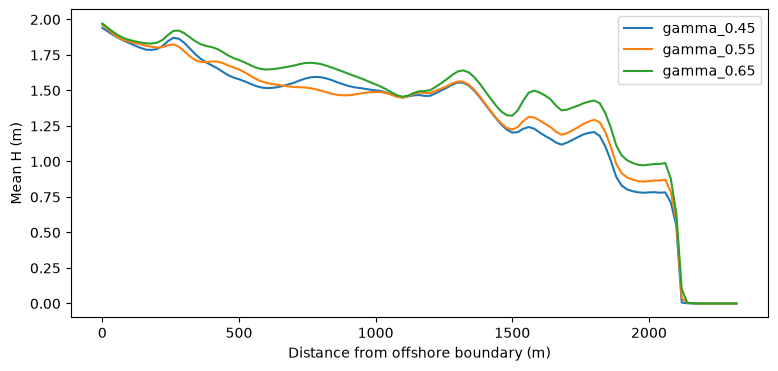

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for run_id, (_, workspace) in workspaces.items():
    outfile = workspace / "xboutput.nc"
    if outfile.exists():
        ds = xr.open_dataset(outfile)
        profile = ds.H_mean.isel(meantime=-1, ny=ds.sizes["ny"] // 2)
        ax.plot(profile.nx * base.grid.dx, profile, label=run_id)
ax.set(xlabel="Distance from offshore boundary (m)", ylabel="Mean H (m)")
ax.legend()
plt.show()

## Summary

- Build one base configuration and derive variants with `model_copy(update=...)`.
- Give each variant its own `run_id` and keep a table of what changed.
- Run the workspaces with any backend and compare the outputs.